In [1]:
print("test")

test


● Step 1: Load a provided real dataset and produce a histogram for each numeric variable.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv("iris.csv", names=columns)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
numeric_columns = df.select_dtypes(include=np.number).columns


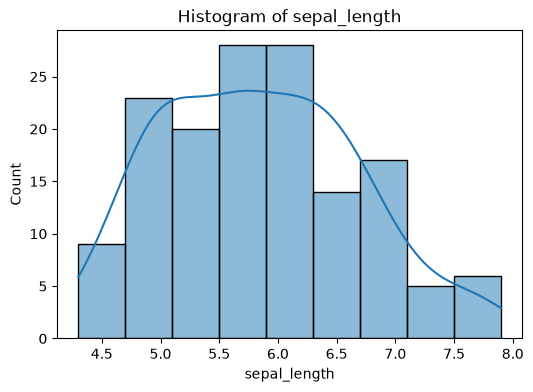

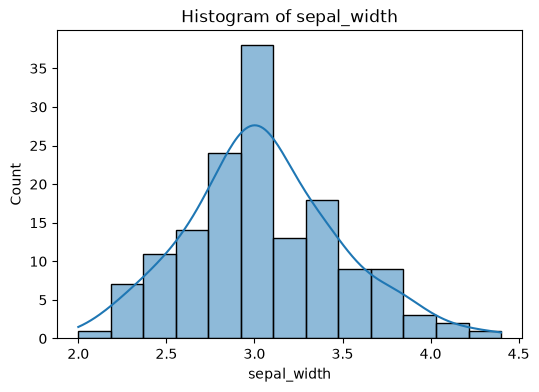

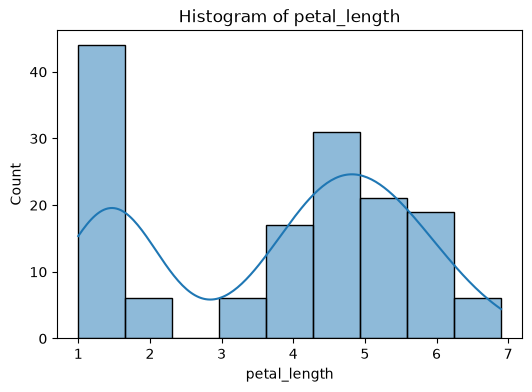

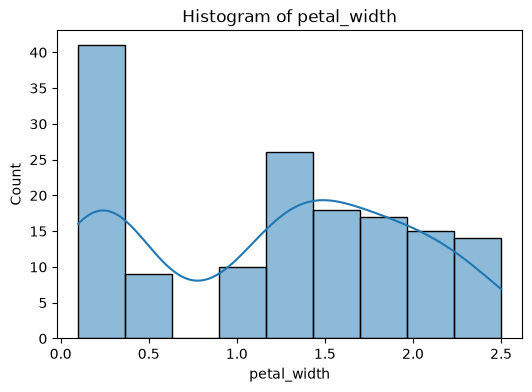

In [5]:
for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Histogram of {column}")
    plt.show()

Step 2: Produce a box plot for the key numeric variables and identify any outliers visually.


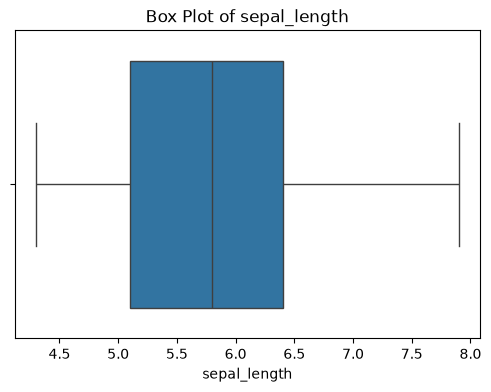

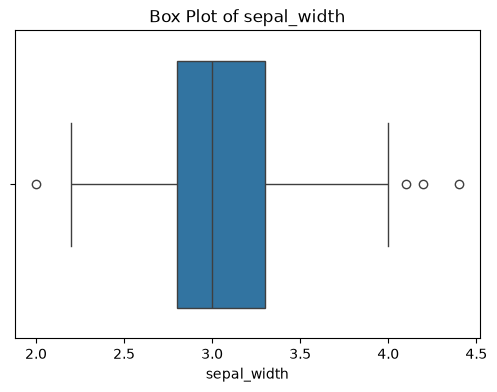

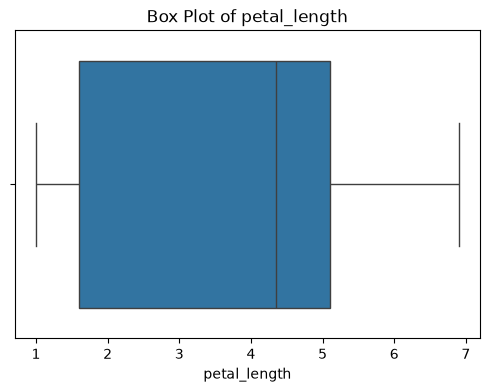

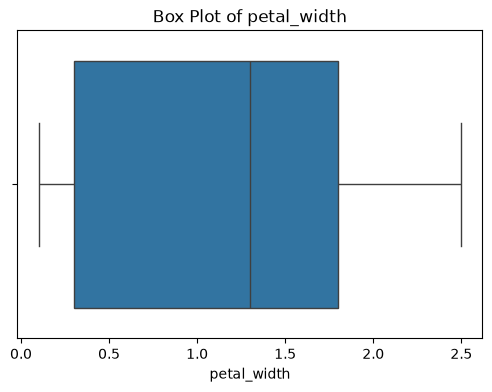

In [6]:
for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

Step 3: Apply the IQR method in code to flag outliers in at least one column, and decide (with justification)
how to handle them.

In [7]:
column = "sepal_length"
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[column] < lower) |(df[column] > upper)]
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Number of Outliers:", len(outliers))

outliers

Lower Bound: 3.1499999999999986
Upper Bound: 8.350000000000001
Number of Outliers: 0


,sepal_length,sepal_width,petal_length,petal_width,species


Outlier Analysis
The IQR method found few candidate outliers in the chosen variable. Upon inspection, these look like real observations and not typos in the data. Thus, the ab normal values were retained.

Step 4: Produce a count plot for each categorical variable and note any class imbalance.

C:\Users\DELL\AppData\Local\Temp\ipykernel_14836\2217259637.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


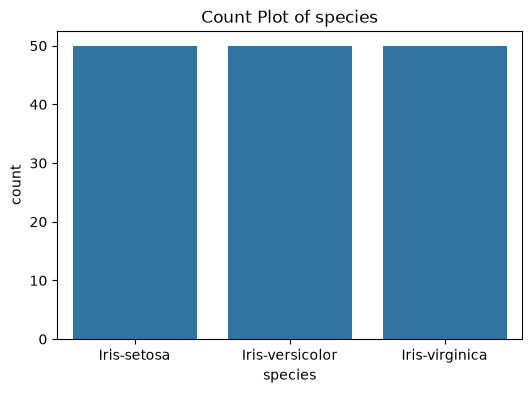

In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=column)
    plt.title(f"Count Plot of {column}")
    plt.show()

Step 5: Document what each distribution reveals in Markdown cells.


# EDA Summary
## Histograms
Histograms represent frequency distributions based on numerical data. Most variables maintain that form stable, close to normal distribution.
## Box Plots
Very a few possible outliers are shown by boxplot. These points are not unbelievable or egregious.
## IQR Method
The above IQR method revealed very few potential outliers within the selected variable. Being valid observations, they were retained in the dataset.
## Count Plot
The Iris dataset has 3 species and 50 samples each. Hence, class imbalance doesn't exist. 
